In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

In [4]:
df = pd.read_csv("../Dataset/placement_predict_50k Dataset.csv")

In [5]:
df.head()

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [6]:
df.tail()

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
49995,49996,Male,Pune,Tier2,Mechanical,Networking,No,No,7.84,8.45,...,1,75.8,3.9,54.2,NaN,0,High,1,0,18.14
49996,49997,Male,Bangalore,Tier2,EE,AI,No,No,6.08,6.12,...,2,81.4,3.8,56.1,67.7,0,Low,1,0,3.36
49997,49998,Male,Ahmedabad,Tier1,Civil,DataScience,Yes,Yes,5.69,6.09,...,0,NaN,3.1,49.1,57.7,1,Low,0,0,0.00
49998,49999,Female,Bangalore,Tier3,CS,DataScience,No,No,6.02,6.31,...,1,74.5,2.5,NaN,48.3,1,Low,0,0,0.00
49999,50000,Female,Delhi,Tier2,ECE,Networking,No,No,6.51,6.37,...,0,58.3,2.3,29.5,30.6,0,Low,0,0,0.00


In [7]:
print(f"Shape of the dataset (Row, Column) = {df.shape}")

Shape of the dataset (Row, Column) = (50000, 32)


In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  str    
 2   City                50000 non-null  str    
 3   CollegeTier         50000 non-null  str    
 4   Stream              50000 non-null  str    
 5   Specialisation      50000 non-null  str    
 6   Hostel              50000 non-null  str    
 7   HistoryOfBacklogs   50000 non-null  str    
 8   SGPA_Sem1           50000 non-null  float64
 9   SGPA_Sem2           50000 non-null  float64
 10  SGPA_Sem3           50000 non-null  float64
 11  SGPA_Sem4           50000 non-null  float64
 12  SGPA_Sem5           50000 non-null  float64
 13  SGPA_Sem6           50000 non-null  float64
 14  SGPA_Sem7           50000 non-null  float64
 15  SGPA_Sem8           50000 non-null  float64
 16  CGPA           

In [9]:
print(df.isnull().sum())

StudentID                0
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
SGPA_Sem1                0
SGPA_Sem2                0
SGPA_Sem3                0
SGPA_Sem4                0
SGPA_Sem5                0
SGPA_Sem6                0
SGPA_Sem7                0
SGPA_Sem8                0
CGPA                     0
AttendancePercent        0
Internships              0
Projects                 0
Workshops             4488
Certifications           0
Publications             0
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
ExtraCurricular          0
CGPA_Tier                0
PlacementStatus          0
IsAnomaly                0
Salary Package           0
dtype: int64


In [10]:
print(df.columns.tolist())

['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']


In [12]:
df['Placed_Flag'] = df['PlacementStatus'].apply(lambda x: 1 if x == "Placed" else 0)

In [14]:
num_cols = ['CGPA', 'AttendancePercent', 'AptitudeTestScore',
            'CodingTestScore', 'SoftSkillsRating', 'Salary Package']

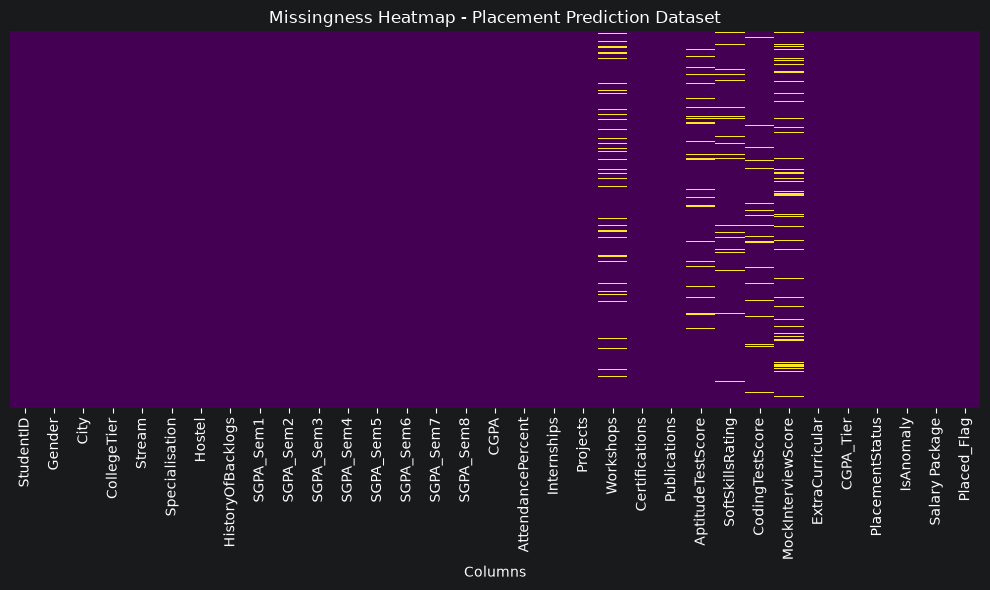

In [15]:
fig1 = plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missingness Heatmap - Placement Prediction Dataset")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()


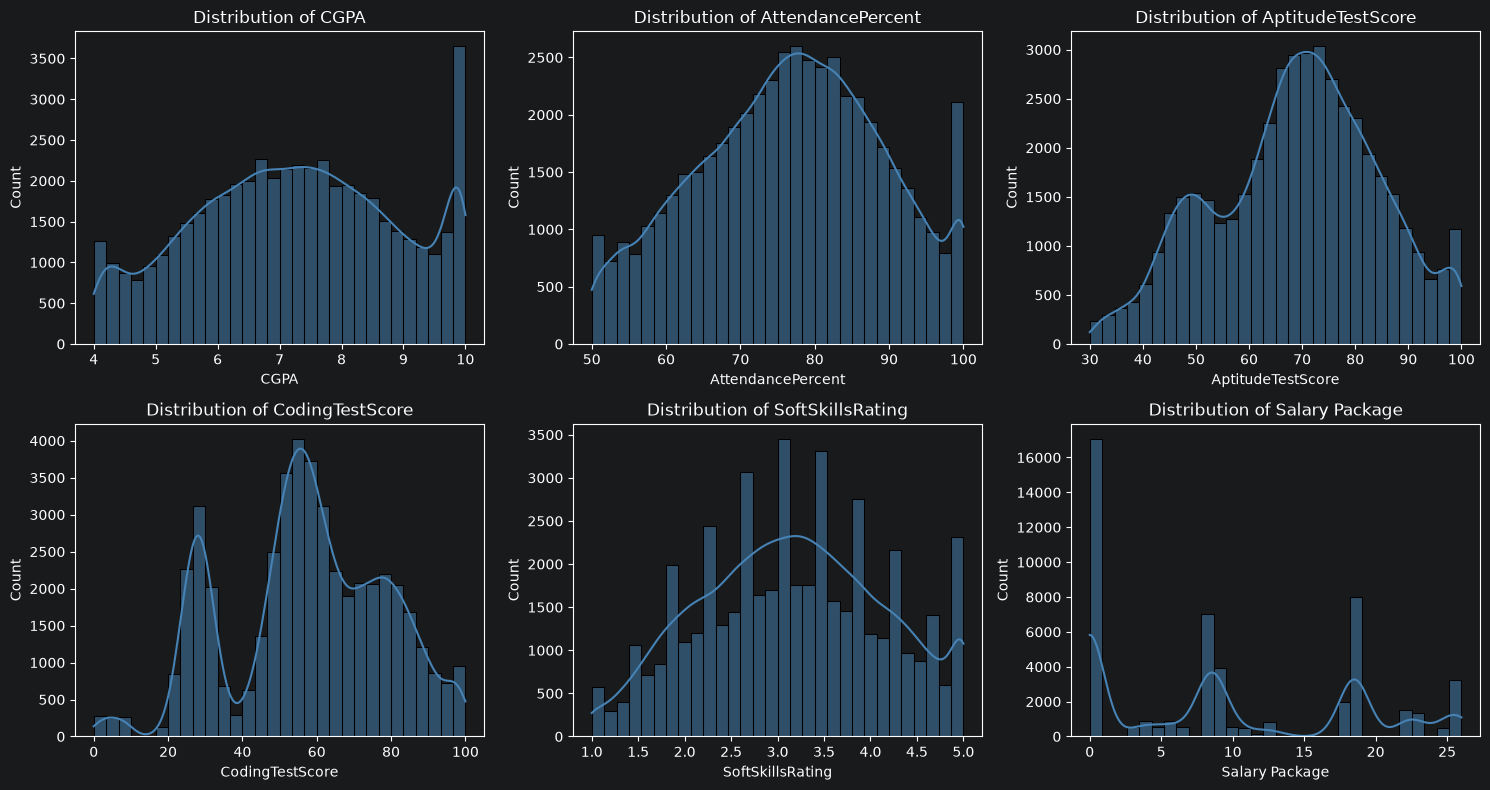

In [16]:
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.histplot(df[col].dropna(), bins=30, kde=True,
                 ax=axes[row, colpos], color='steelblue')
    axes[row, colpos].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()
